In [1]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import pandas as pd
import numpy as np

import time
from datetime import datetime, timedelta
import os
import numpy as np
import pandas as pd
import requests


from web3 import Web3

from dotenv import load_dotenv
load_dotenv()

True

# EDA: Динамика комиссий Ethereum (апрель 2025 — апрель 2026)

In [2]:
plt.rcParams.update({
    "figure.facecolor": "#0d1117",
    "axes.facecolor":   "#0d1117",
    "axes.edgecolor":   "#30363d",
    "axes.labelcolor":  "#c9d1d9",
    "text.color":       "#c9d1d9",
    "xtick.color":      "#8b949e",
    "ytick.color":      "#8b949e",
    "grid.color":       "#21262d",
    "grid.linewidth":   0.6,
    "font.family":      "DejaVu Sans",
    "font.size":        11,
    "axes.titlesize":   13,
    "axes.titleweight": "bold",
})

C_BASE  = "#0098AF"   # teal  — base fee
C_PRIO  = "#355CA8"   # blue  — priority fee
C_ETH   = "#f0b429"   # amber — ETH price
C_FILL  = "#0098AF22"


prio_df = pd.read_csv(
    "data/priority_with_price_until_april.csv",
    usecols=["timestamp", "base_fee_per_gas", "priority_p50", "last_eth_price"],
    parse_dates=["timestamp"],
)
prio_df["base_gwei"] = prio_df["base_fee_per_gas"] / 1e9
prio_df["prio_gwei"] = prio_df["priority_p50"]      / 1e9
prio_df = prio_df.sort_values("timestamp").set_index("timestamp")


daily = prio_df[["base_gwei", "prio_gwei", "last_eth_price"]].resample("D").median()
daily["base_roll7"]  = daily["base_gwei"].rolling(7,  center=True).mean()
daily["base_roll30"] = daily["base_gwei"].rolling(30, center=True).mean()
daily["prio_roll7"]  = daily["prio_gwei"].rolling(7,  center=True).mean()



In [4]:
print(f"Строк (блоков): {len(prio_df):,}")
print(f"Период: {prio_df.index.min().date()} → {prio_df.index.max().date()}")
print(f"\nBase fee — макс: {daily.base_gwei.max():.2f} Gwei, мин: {daily.base_gwei.min():.3f} Gwei")
print(f"Priority (p50) — макс: {daily.prio_gwei.max():.3f} Gwei, мин: {daily.prio_gwei.min():.4f} Gwei")

Строк (блоков): 2,616,616
Период: 2025-04-15 → 2026-04-15

Base fee — макс: 4.54 Gwei, мин: 0.024 Gwei
Priority (p50) — макс: 1.000 Gwei, мин: 0.0014 Gwei


## 1. Долгосрочный тренд: base fee и priority fee за год

In [5]:
plt.style.use("default")

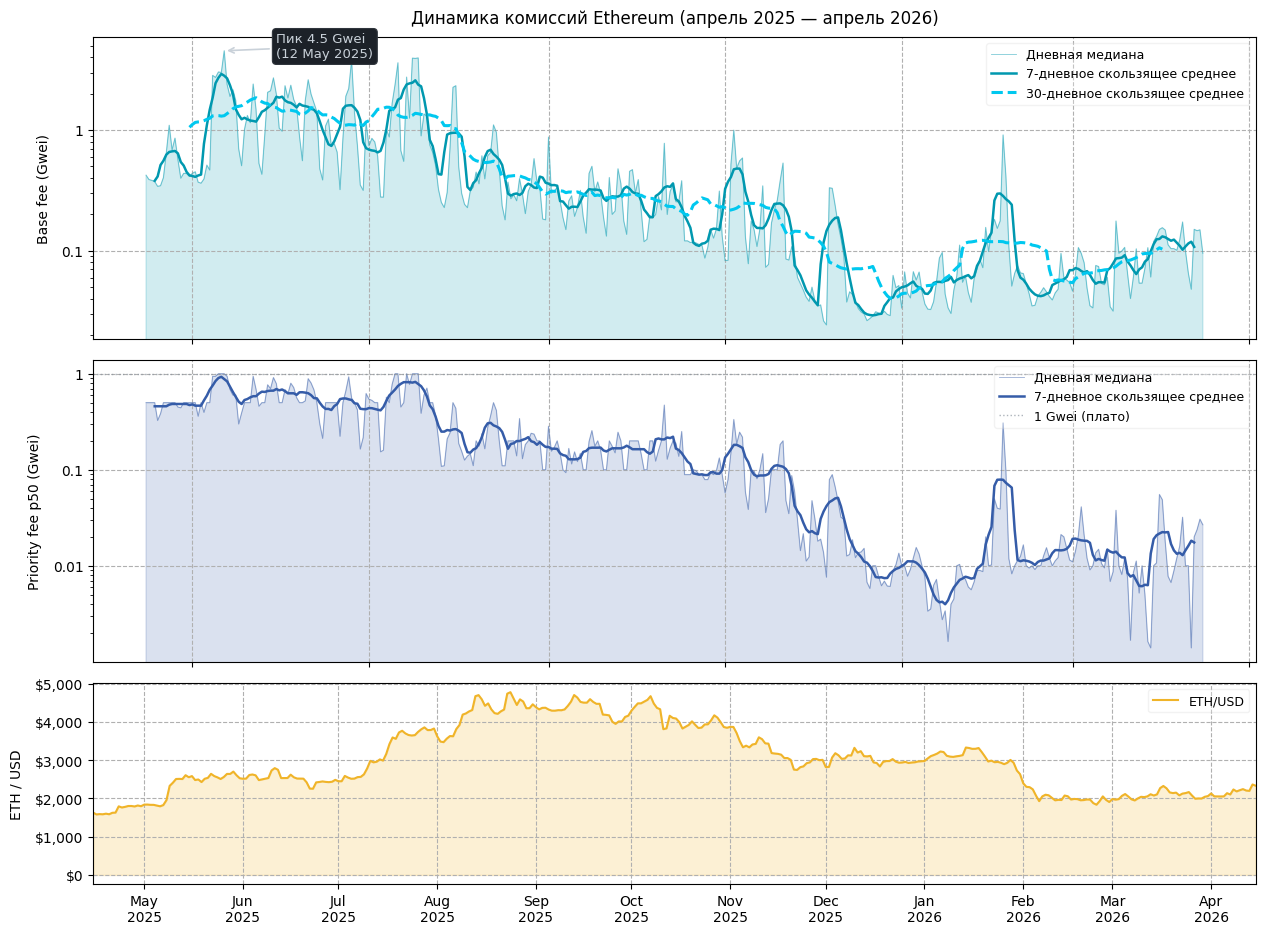

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(15, 11),
                         gridspec_kw={"height_ratios": [3, 3, 2], "hspace": 0.08})


ax = axes[0]
ax.fill_between(daily.index, daily["base_gwei"], alpha=0.18, color=C_BASE)
ax.plot(daily.index, daily["base_gwei"],  color=C_BASE,  lw=0.6, alpha=0.5, label="Дневная медиана")
ax.plot(daily.index, daily["base_roll7"], color=C_BASE,  lw=1.8, label="7-дневное скользящее среднее")
ax.plot(daily.index, daily["base_roll30"],color="#00c8ef",lw=2.2, ls="--", label="30-дневное скользящее среднее")

# Аннотация пика
peak_d = daily["base_gwei"].idxmax()
peak_v = daily["base_gwei"].max()
ax.annotate(
    f"Пик {peak_v:.1f} Gwei\n({peak_d.strftime('%d %b %Y')})",
    xy=(peak_d, peak_v),
    xytext=(peak_d + pd.Timedelta(days=18), peak_v * 0.88),
    arrowprops=dict(arrowstyle="->", color="#c9d1d9", lw=1.2),
    fontsize=9.5, color="#c9d1d9",
    bbox=dict(boxstyle="round,pad=0.3", fc="#1c2128", ec="#30363d", lw=0.8),
)

ax.set_ylabel("Base fee (Gwei)", labelpad=8)
ax.set_yscale("log")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:g}"))
ax.legend(loc="upper right", framealpha=0.25, fontsize=9)
ax.grid(True, axis="both", ls="--")
ax.set_xticklabels([])
ax.set_title("Динамика комиссий Ethereum (апрель 2025 — апрель 2026)", pad=10)


ax = axes[1]
ax.fill_between(daily.index, daily["prio_gwei"], alpha=0.18, color=C_PRIO)
ax.plot(daily.index, daily["prio_gwei"],  color=C_PRIO,  lw=0.6, alpha=0.5, label="Дневная медиана")
ax.plot(daily.index, daily["prio_roll7"], color=C_PRIO,  lw=1.8, label="7-дневное скользящее среднее")

# Показываем «плато» на уровне 1 Gwei (hard-cap в период мая-июля)
ax.axhline(1.0, ls=":", color="#8b949e", lw=1.0, alpha=0.7, label="1 Gwei (плато)")

ax.set_ylabel("Priority fee p50 (Gwei)", labelpad=8)
ax.set_yscale("log")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:g}"))
ax.legend(loc="upper right", framealpha=0.25, fontsize=9)
ax.grid(True, axis="both", ls="--")
ax.set_xticklabels([])

ax = axes[2]
ax.fill_between(daily.index, daily["last_eth_price"], alpha=0.20, color=C_ETH)
ax.plot(daily.index, daily["last_eth_price"], color=C_ETH, lw=1.5, label="ETH/USD")
ax.set_ylabel("ETH / USD", labelpad=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend(loc="upper right", framealpha=0.25, fontsize=9)
ax.grid(True, axis="both", ls="--")

# Единая ось X для нижнего графика
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
ax.set_xlim(daily.index[0], daily.index[-1])

# plt.savefig("eda_trend.png", dpi=150, bbox_inches="tight") #, facecolor="white")
plt.show()

## 2. Сезонность: суточный и недельный цикл

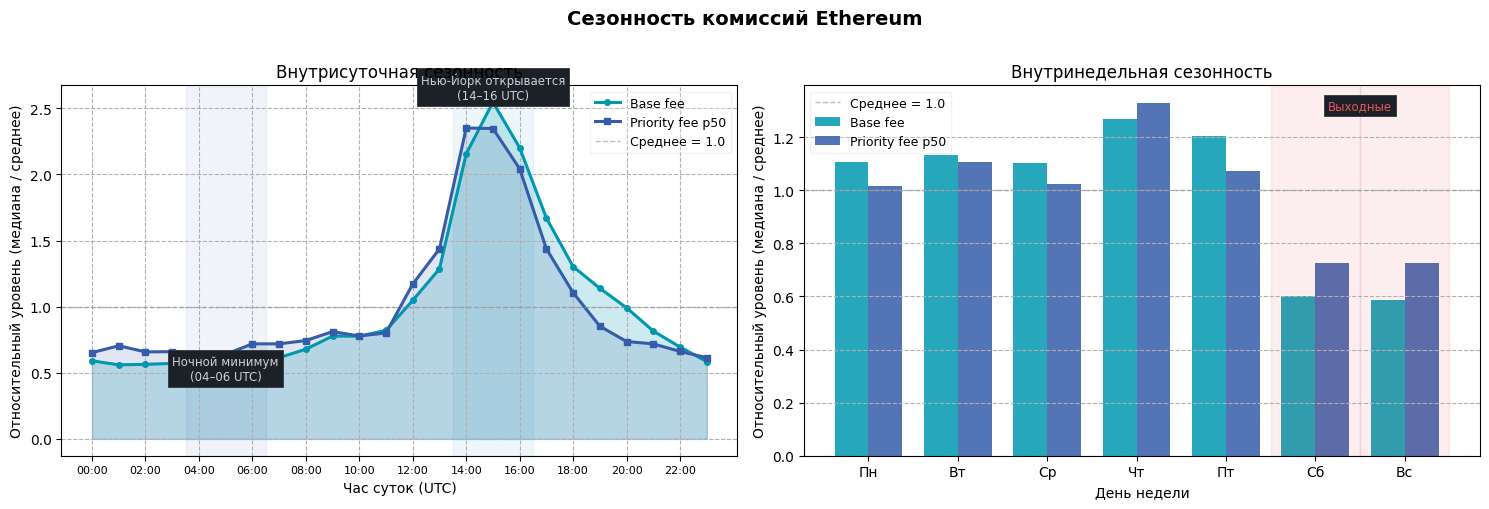

In [ ]:
prio_df["hour"] = prio_df.index.hour
prio_df["dow"]  = prio_df.index.dayofweek   # 0=Пн … 6=Вс

hourly_med = prio_df.groupby("hour")[["base_gwei", "prio_gwei"]].median()
dow_med    = prio_df.groupby("dow")[["base_gwei", "prio_gwei"]].median()
dow_labels = ["Пн", "Вт", "Ср", "Чт", "Пт", "Сб", "Вс"]

# Нормируем: доля от среднесуточного (показывает относительное отклонение)
hourly_norm = hourly_med.div(hourly_med.mean())
dow_norm    = dow_med.div(dow_med.mean())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Сезонность комиссий Ethereum", fontsize=14, fontweight="bold", y=1.01)

# ── Суточный цикл ────────────────────────────────────────────────────────
ax = axes[0]
x = hourly_norm.index

ax.fill_between(x, hourly_norm["base_gwei"], alpha=0.20, color=C_BASE)
ax.plot(x, hourly_norm["base_gwei"], color=C_BASE,  lw=2.2, marker="o", ms=4, label="Base fee")
ax.fill_between(x, hourly_norm["prio_gwei"], alpha=0.15, color=C_PRIO)
ax.plot(x, hourly_norm["prio_gwei"], color=C_PRIO, lw=2.2, marker="s", ms=4, label="Priority fee p50")

ax.axhline(1.0, ls="--", color="#8b949e", lw=1.0, alpha=0.6, label="Среднее = 1.0")

# Аннотируем пик (14-16 UTC = утро Нью-Йорка)
peak_h = hourly_norm["base_gwei"].idxmax()
ax.axvspan(13.5, 16.5, alpha=0.07, color=C_BASE)
ax.text(15, hourly_norm["base_gwei"].max() * 1.01,
        "Нью-Йорк открывается\n(14–16 UTC)", ha="center", fontsize=8.5, color="#c9d1d9",
        bbox=dict(fc="#1c2128", ec="#30363d", lw=0.6, pad=3))

# Ночной минимум
ax.axvspan(3.5, 6.5, alpha=0.07, color=C_PRIO)
ax.text(5, hourly_norm["base_gwei"].min() * 0.87,
        "Ночной минимум\n(04–06 UTC)", ha="center", fontsize=8.5, color="#c9d1d9",
        bbox=dict(fc="#1c2128", ec="#30363d", lw=0.6, pad=3))

ax.set_xlabel("Час суток (UTC)")
ax.set_ylabel("Относительный уровень (медиана / среднее)")
ax.set_title("Внутрисуточная сезонность")
ax.set_xticks(range(0, 24, 2))
ax.set_xticklabels([f"{h:02d}:00" for h in range(0, 24, 2)], fontsize=8)
ax.legend(fontsize=9, framealpha=0.25)
ax.grid(True, ls="--")

# Недельный цикл
ax = axes[1]
x2 = np.arange(7)
width = 0.38

bars1 = ax.bar(x2 - width/2, dow_norm["base_gwei"],  width, color=C_BASE, alpha=0.85, label="Base fee")
bars2 = ax.bar(x2 + width/2, dow_norm["prio_gwei"], width, color=C_PRIO, alpha=0.85, label="Priority fee p50")

ax.axhline(1.0, ls="--", color="#8b949e", lw=1.0, alpha=0.6, label="Среднее = 1.0")

# Подсветка выходных
for xi in [5, 6]:
    ax.axvspan(xi - 0.5, xi + 0.5, alpha=0.07, color="#D80F16")
ax.text(5.5, dow_norm["base_gwei"].max() * 1.03,
        "Выходные", ha="center", fontsize=8.5, color="#e85560",
        bbox=dict(fc="#1c2128", ec="#30363d", lw=0.6, pad=3))

ax.set_xlabel("День недели")
ax.set_ylabel("Относительный уровень (медиана / среднее)")
ax.set_title("Внутринедельная сезонность")
ax.set_xticks(x2)
ax.set_xticklabels(dow_labels)
ax.legend(fontsize=9, framealpha=0.25)
ax.grid(True, axis="y", ls="--")

plt.tight_layout()
# plt.savefig("eda_seasonality.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()